In [1]:
import polars as pl
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent 
data = pl.read_parquet(PROJECT_ROOT / "data/raw/20250811_bgg.parquet")

In [3]:
data['mechanics']

mechanics
list[str]
"[""Alliances"", ""Area Majority / Influence"", … ""Simultaneous Action Selection""]"
"[""Trick-taking""]"
"[""Area Majority / Influence"", ""Hand Management"", … ""Tile Placement""]"
"[""Action Points"", ""Area Majority / Influence"", … ""Set Collection""]"
"[""Connections"", ""End Game Bonuses"", … ""Victory Points as a Resource""]"
…
[]
"[""Dice Rolling"", ""Paper-and-Pencil""]"
"[""Deck, Bag, and Pool Building"", ""Modular Board"", … ""Variable Player Powers""]"


Let's filter games without mechanics.

In [4]:
df_filtered = data.filter(
    pl.col("mechanics").is_not_null() & (pl.col("mechanics").list.len() > 0)
)

print(f"Original rows: {data.height}")
print(f"Filtered rows: {df_filtered.height}")

Original rows: 88465
Filtered rows: 74577


Are there any other empty games?

In [5]:
df_sorted = df_filtered.with_columns(
    mechanics_str = pl.col("mechanics").list.join(", ")
).sort(
    by=pl.col("mechanics_str").str.len_chars(),
    descending=False
)

df_sorted["mechanics"].head(10)

mechanics
list[str]
"[""Race""]"
"[""Race""]"
"[""Race""]"
"[""Race""]"
"[""Race""]"
"[""Race""]"
"[""Race""]"
"[""Race""]"
"[""Race""]"


Let's understand mechanics distribution

In [6]:
mechanic_counts = (
    df_filtered
    .select(
        pl.col("mechanics")
    )
    .explode("mechanics")        
    .group_by("mechanics")       
    .len()                       
    .sort("len", descending=True)                 
)

In [7]:
mechanic_counts

mechanics,len
str,u32
"""Dice Rolling""",19905
"""Roll / Spin and Move""",14572
"""Hand Management""",10573
"""Set Collection""",10285
"""Hexagon Grid""",5933
…,…
"""Auction: Dutch Priority""",6
"""Auction Compensation""",5
"""Auction: Dexterity""",4


In [8]:
stats = mechanic_counts.select(
    pl.col("len").min().alias("min"),
    pl.col("len").quantile(0.25).alias("25%"),
    pl.col("len").median().alias("median"),
    pl.col("len").quantile(0.75).alias("75%"),
    pl.col("len").quantile(0.90).alias("90%"),
    pl.col("len").max().alias("max"),
    pl.col("len").mean().alias("mean")
)
print(stats)

shape: (1, 7)
┌─────┬──────┬────────┬───────┬────────┬───────┬────────────┐
│ min ┆ 25%  ┆ median ┆ 75%   ┆ 90%    ┆ max   ┆ mean       │
│ --- ┆ ---  ┆ ---    ┆ ---   ┆ ---    ┆ ---   ┆ ---        │
│ u32 ┆ f64  ┆ f64    ┆ f64   ┆ f64    ┆ u32   ┆ f64        │
╞═════╪══════╪════════╪═══════╪════════╪═══════╪════════════╡
│ 3   ┆ 36.0 ┆ 81.0   ┆ 656.0 ┆ 2883.0 ┆ 19905 ┆ 934.614583 │
└─────┴──────┴────────┴───────┴────────┴───────┴────────────┘


Let's try to do an elbow elimination approach

In [9]:
max_count = mechanic_counts["len"].max()

threshold_data = (
    pl.DataFrame({"threshold": range(1, max_count + 1)})
    .with_columns(
        pl.col("threshold").map_elements(
            lambda t: mechanic_counts.filter(pl.col("len") >= t).height,
            return_dtype=pl.Int64
        ).alias("mechanics_kept")
    )
)

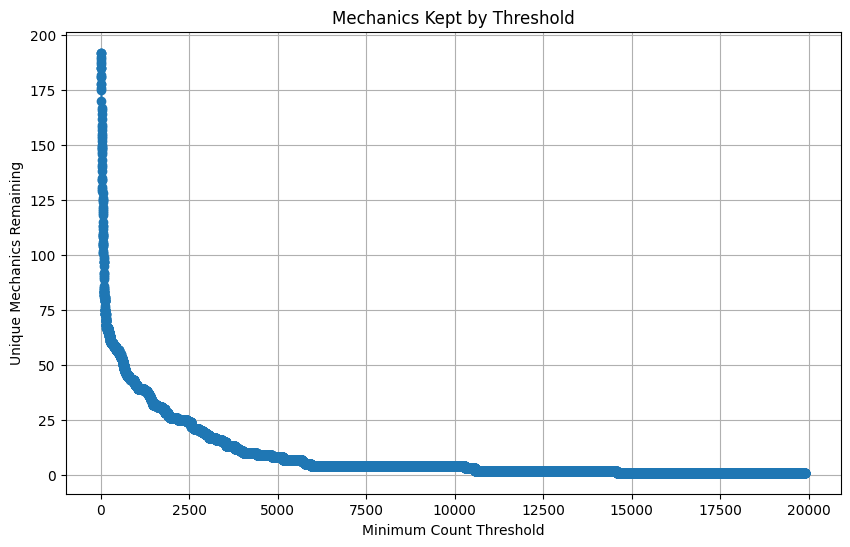

In [10]:
import matplotlib.pyplot as plt

plot_data = threshold_data.to_pandas()

plt.figure(figsize=(10, 6))
plt.plot(plot_data["threshold"], plot_data["mechanics_kept"], marker='o')

plt.title("Mechanics Kept by Threshold")
plt.xlabel("Minimum Count Threshold")
plt.ylabel("Unique Mechanics Remaining")
plt.grid(True)
plt.show()

It seems to drop drastically until around 80 games, but reducing the number of categories by half feels too drastic imo.

In [11]:
filtered_stats = threshold_data.filter(pl.col("threshold") < 20)

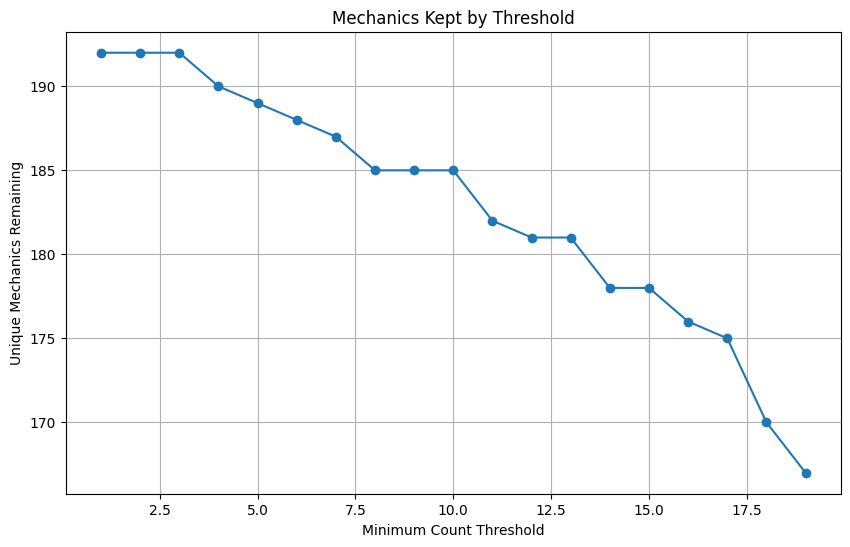

In [12]:
plot_data = filtered_stats.to_pandas()

plt.figure(figsize=(10, 6))
plt.plot(plot_data["threshold"], plot_data["mechanics_kept"], marker='o')

plt.title("Mechanics Kept by Threshold")
plt.xlabel("Minimum Count Threshold")
plt.ylabel("Unique Mechanics Remaining")
plt.grid(True)
plt.show()

Do we lose any games by defining a treshold of 10?

In [13]:
valid_mechanics = (
    data.explode("mechanics")
    .group_by("mechanics")
    .len()
    .filter(pl.col("len") >= 10)
    .select("mechanics")
)

df_clean = (
    data.with_row_index("row_id")
    .explode("mechanics")        
    .join(
        valid_mechanics, 
        on="mechanics", 
        how="inner"           
    )
    .group_by("row_id")       
    .agg(pl.col("mechanics")) 
    .sort("row_id")           
    .drop("row_id")          
)

print(df_clean)

shape: (74_576, 1)
┌─────────────────────────────────┐
│ mechanics                       │
│ ---                             │
│ list[str]                       │
╞═════════════════════════════════╡
│ ["Alliances", "Area Majority /… │
│ ["Trick-taking"]                │
│ ["Area Majority / Influence", … │
│ ["Action Points", "Area Majori… │
│ ["Connections", "End Game Bonu… │
│ …                               │
│ ["Dice Rolling", "Player Elimi… │
│ ["Dice Rolling", "Paper-and-Pe… │
│ ["Deck, Bag, and Pool Building… │
│ ["Dice Rolling"]                │
│ ["Market", "Set Collection"]    │
└─────────────────────────────────┘


74577 -> 74576. This looks fine.

Let's just look at the 80 treshold (curiosity).

In [14]:
valid_mechanics = (
    data.explode("mechanics")
    .group_by("mechanics")
    .len()
    .filter(pl.col("len") >= 81)
    .select("mechanics")
)

df_clean = (
    data.with_row_index("row_id")
    .explode("mechanics")        
    .join(
        valid_mechanics, 
        on="mechanics", 
        how="inner"           
    )
    .group_by("row_id")       
    .agg(pl.col("mechanics")) 
    .sort("row_id")           
    .drop("row_id")          
)

print(df_clean)

shape: (74_496, 1)
┌─────────────────────────────────┐
│ mechanics                       │
│ ---                             │
│ list[str]                       │
╞═════════════════════════════════╡
│ ["Area Majority / Influence", … │
│ ["Trick-taking"]                │
│ ["Area Majority / Influence", … │
│ ["Action Points", "Area Majori… │
│ ["Connections", "End Game Bonu… │
│ …                               │
│ ["Dice Rolling", "Player Elimi… │
│ ["Dice Rolling", "Paper-and-Pe… │
│ ["Deck, Bag, and Pool Building… │
│ ["Dice Rolling"]                │
│ ["Market", "Set Collection"]    │
└─────────────────────────────────┘


In [15]:
filtered_stats = threshold_data.filter(pl.col("threshold") < 81)

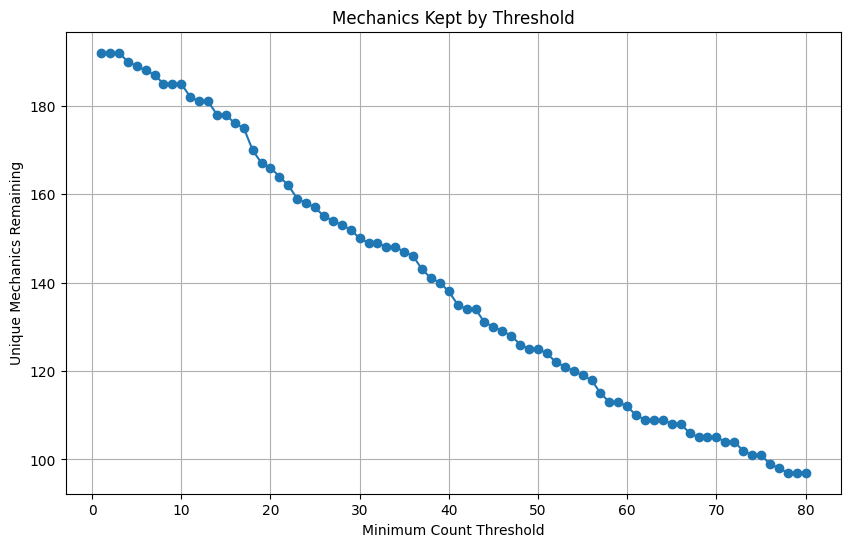

In [16]:
plot_data = filtered_stats.to_pandas()

plt.figure(figsize=(10, 6))
plt.plot(plot_data["threshold"], plot_data["mechanics_kept"], marker='o')

plt.title("Mechanics Kept by Threshold")
plt.xlabel("Minimum Count Threshold")
plt.ylabel("Unique Mechanics Remaining")
plt.grid(True)
plt.show()

We reduced the number of mechanics almost by half.

Let's now check correlation

In [17]:
df_id = df_clean.with_row_index("game_id")
df_exploded = df_id.explode("mechanics")
df_matrix = (
    df_exploded
    .pivot(
        on="mechanics", 
        index="game_id", 
        values="mechanics", 
        aggregate_function="len"
    )
    .fill_null(0)
)

print(df_matrix.head())

shape: (5, 98)
┌─────────┬────────────┬────────────┬────────────┬───┬────────────┬───────────┬───────────┬────────┐
│ game_id ┆ Area       ┆ Auction /  ┆ Dice       ┆ … ┆ Communicat ┆ Re-rollin ┆ Deck,     ┆ Turn   │
│ ---     ┆ Majority / ┆ Bidding    ┆ Rolling    ┆   ┆ ion Limits ┆ g and     ┆ Bag, and  ┆ Order: │
│ u32     ┆ Influence  ┆ ---        ┆ ---        ┆   ┆ ---        ┆ Locking   ┆ Pool      ┆ Time   │
│         ┆ ---        ┆ u32        ┆ u32        ┆   ┆ u32        ┆ ---       ┆ Building  ┆ Track  │
│         ┆ u32        ┆            ┆            ┆   ┆            ┆ u32       ┆ ---       ┆ ---    │
│         ┆            ┆            ┆            ┆   ┆            ┆           ┆ u32       ┆ u32    │
╞═════════╪════════════╪════════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪════════╡
│ 0       ┆ 1          ┆ 1          ┆ 1          ┆ … ┆ 0          ┆ 0         ┆ 0         ┆ 0      │
│ 1       ┆ 0          ┆ 0          ┆ 0          ┆ … ┆ 0          ┆ 0       

In [18]:
mechanic_cols = [col for col in df_matrix.columns if col != "game_id"]

corr_matrix = df_matrix.select(mechanic_cols).corr()

print(corr_matrix)

shape: (97, 97)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Area      ┆ Auction / ┆ Dice      ┆ Hand Mana ┆ … ┆ Communica ┆ Re-rollin ┆ Deck,     ┆ Turn     │
│ Majority  ┆ Bidding   ┆ Rolling   ┆ gement    ┆   ┆ tion      ┆ g and     ┆ Bag, and  ┆ Order:   │
│ /         ┆ ---       ┆ ---       ┆ ---       ┆   ┆ Limits    ┆ Locking   ┆ Pool      ┆ Time     │
│ Influence ┆ f64       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ Building  ┆ Track    │
│ ---       ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ ---       ┆ ---      │
│ f64       ┆           ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ 0.011966  ┆ 0.007772  ┆ 0.055362  ┆ … ┆ -0.004263 ┆ 0.003209  ┆ 0.0369    ┆ 0.017765 │
│ 0.011966  ┆ 1.0       ┆ -0.07946  ┆ -0.018203 ┆ … ┆ -0.006028 ┆ -0.00606 

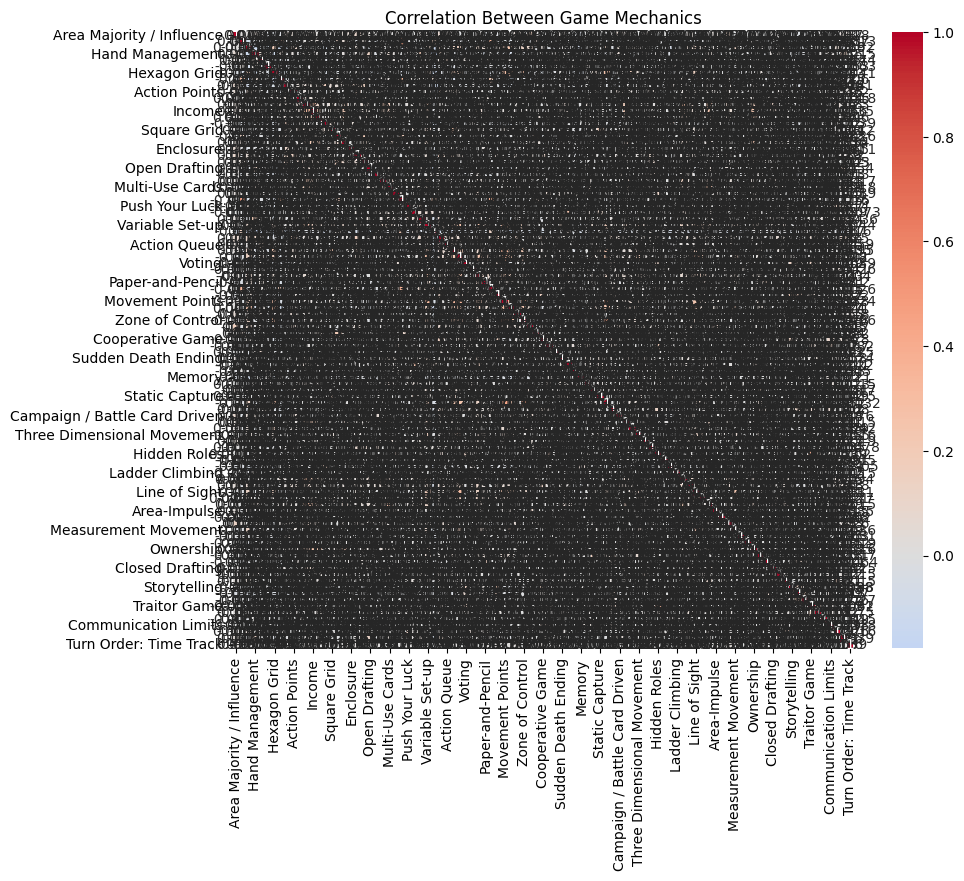

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf_corr = corr_matrix.to_pandas()

pdf_corr.index = pdf_corr.columns

plt.figure(figsize=(10, 8))
sns.heatmap(pdf_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Game Mechanics")
plt.show()

In [20]:
ranked_correlations = (
    corr_matrix
    .with_columns(pl.Series("mechanic_1", mechanic_cols))
    .unpivot(
        index=["mechanic_1"], 
        variable_name="mechanic_2", 
        value_name="correlation"
    )
    .filter(pl.col("mechanic_1") < pl.col("mechanic_2"))
    .sort("correlation", descending=True)
)

print(ranked_correlations.head(20))

shape: (20, 3)
┌──────────────────────────────┬──────────────────────────────┬─────────────┐
│ mechanic_1                   ┆ mechanic_2                   ┆ correlation │
│ ---                          ┆ ---                          ┆ ---         │
│ str                          ┆ str                          ┆ f64         │
╞══════════════════════════════╪══════════════════════════════╪═════════════╡
│ Ratio / Combat Results Table ┆ Zone of Control              ┆ 0.474685    │
│ Auction / Bidding            ┆ Trading                      ┆ 0.445309    │
│ Movement Points              ┆ Ratio / Combat Results Table ┆ 0.436994    │
│ Movement Points              ┆ Zone of Control              ┆ 0.405696    │
│ Hidden Roles                 ┆ Traitor Game                 ┆ 0.371513    │
│ …                            ┆ …                            ┆ …           │
│ Contracts                    ┆ End Game Bonuses             ┆ 0.287556    │
│ Hexagon Grid                 ┆ Movement Points 

It's too low to merge.

Let's use hierarchical clustering to try and form clusters of categories.

In [28]:
import scipy.cluster.hierarchy as sch

df_corr_pandas = corr_matrix.to_pandas()
df_corr_pandas.index = mechanic_cols 
df_corr_pandas.columns = mechanic_cols

/tmp/ipykernel_25287/4062568881.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(distance_matrix, method='ward')


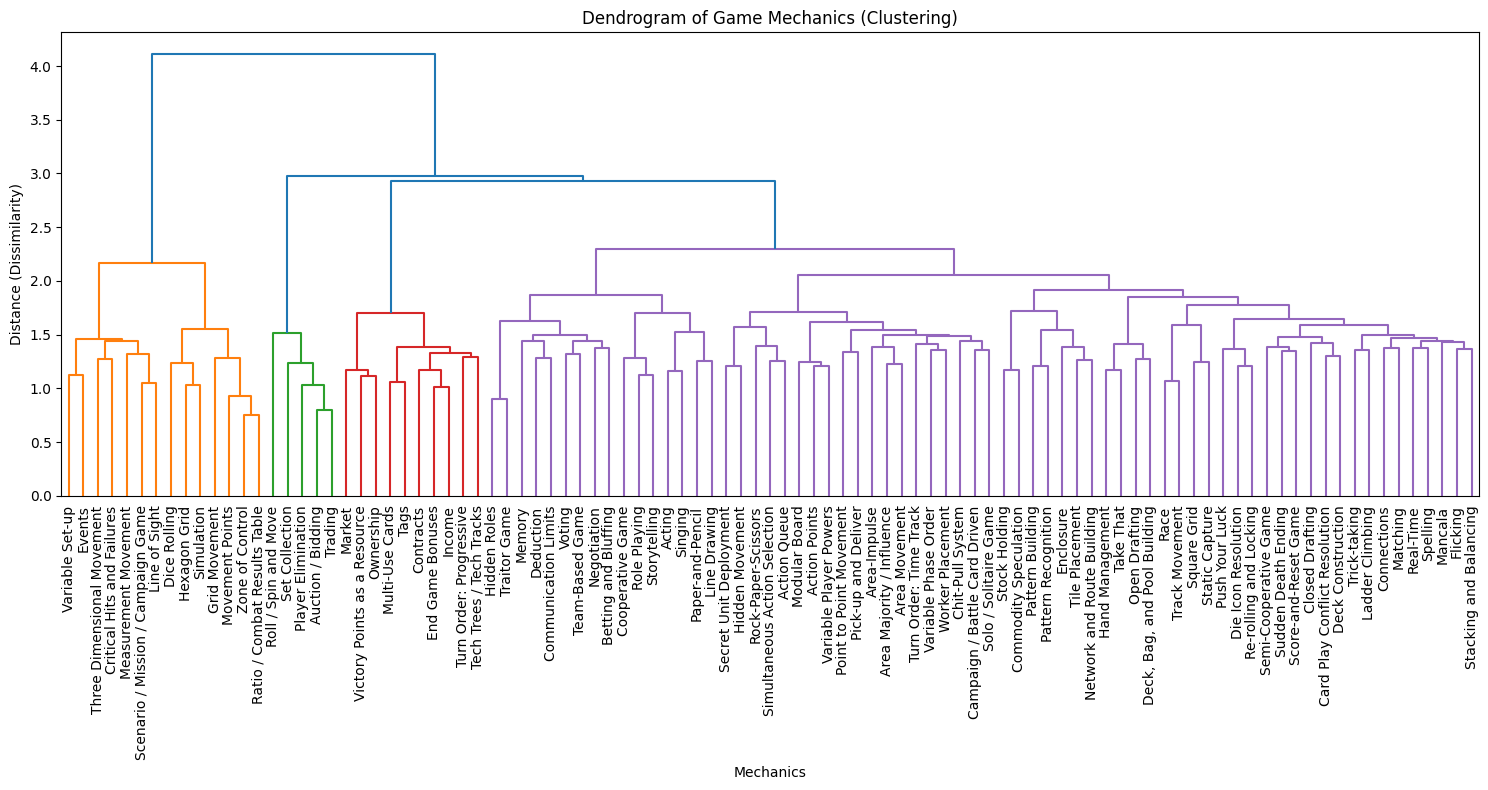

In [29]:
distance_matrix = 1 - df_corr_pandas
linkage_matrix = sch.linkage(distance_matrix, method='ward')

plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(
    linkage_matrix,
    labels=df_corr_pandas.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Dendrogram of Game Mechanics (Clustering)")
plt.xlabel("Mechanics")
plt.ylabel("Distance (Dissimilarity)")
plt.tight_layout()
plt.show()